# CPU Utilization Visualization

Visualize CPU utilization results from `run_utilization_experiments.py`.

Configure the dataset, number of cores, and which config IDs to plot below.

In [1]:
import os
import csv
import glob
import random

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
DATASET = "PokerHand"  # Dataset name used in the experiment
BASE_DIR = "utilization_experiments"  # Base directory for results

# Number of cores to display in the utilization plot
# Options: 1, 2, or 4
NUM_CORES = 4

# All core counts used in the experiments (for the speedup plot)
ALL_CORE_COUNTS = [1, 2, 4]

DETECTORS = ["bndm", "csddm", "d3", "ibdd", "ocdd", "spll", "udetect"]

# Which config IDs to plot per detector.
# Options:
#   "all"          - plot all available IDs
#   "random"       - plot one random ID per detector
#   <int>          - plot a specific ID (e.g. 0)
#   <list of int>  - plot specific IDs (e.g. [0, 2, 5])
SELECTED_IDS = "all"

In [3]:
def results_dir(base, cores):
    """Return the results directory for a given core count."""
    return os.path.join(base, f"{cores}_cores")


def load_cpu_csv(filepath):
    """Load a CPU utilization CSV and return (relative_times, utilizations)."""
    timestamps = []
    utilizations = []
    with open(filepath, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            timestamps.append(float(row["time"]))
            utilizations.append(float(row["cpu_util_avg"]))
    if not timestamps:
        return np.array([]), np.array([])
    # Convert to relative time (seconds from start)
    t0 = timestamps[0]
    rel_times = np.array([t - t0 for t in timestamps])
    return rel_times, np.array(utilizations)


def load_config_file(filepath):
    """Load a .config file and return a dict mapping id -> param dict."""
    configs = {}
    with open(filepath, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            cid = int(row["id"])
            params = {k: v for k, v in row.items() if k != "id"}
            configs[cid] = params
    return configs


def discover_ids(dataset, detector, rdir):
    """Find all available config IDs for a dataset/detector pair."""
    pattern = os.path.join(rdir, f"{dataset}_{detector}_*.csv")
    files = glob.glob(pattern)
    ids = []
    for f in files:
        basename = os.path.basename(f)
        prefix = f"{dataset}_{detector}_"
        if basename.startswith(prefix) and basename.endswith(".csv"):
            id_str = basename[len(prefix):-4]
            try:
                ids.append(int(id_str))
            except ValueError:
                pass
    return sorted(ids)


def resolve_ids(selected, available_ids):
    """Resolve the SELECTED_IDS setting into a list of IDs."""
    if not available_ids:
        return []
    if selected == "all":
        return available_ids
    if selected == "random":
        return [random.choice(available_ids)]
    if isinstance(selected, int):
        return [selected] if selected in available_ids else []
    if isinstance(selected, list):
        return [i for i in selected if i in available_ids]
    return available_ids


def get_duration(filepath):
    """Get the total duration (last - first timestamp) from a CSV."""
    times, _ = load_cpu_csv(filepath)
    if len(times) < 2:
        return None
    return times[-1] - times[0]

In [4]:
# Discover and display available data for the selected core count
rdir = results_dir(BASE_DIR, NUM_CORES)
print(f"Results directory: {rdir}")
print()
for det in DETECTORS:
    ids = discover_ids(DATASET, det, rdir)
    config_path = os.path.join(rdir, f"{DATASET}_{det}.config")
    n_configs = 0
    if os.path.exists(config_path):
        n_configs = len(load_config_file(config_path))
    print(f"{det.upper():>10s}: {len(ids)} result files, {n_configs} configs")

Results directory: utilization_experiments/4_cores

      BNDM: 48 result files, 48 configs
     CSDDM: 32 result files, 32 configs
        D3: 36 result files, 36 configs
      IBDD: 25 result files, 72 configs
      OCDD: 16 result files, 16 configs
      SPLL: 16 result files, 16 configs
   UDETECT: 24 result files, 24 configs


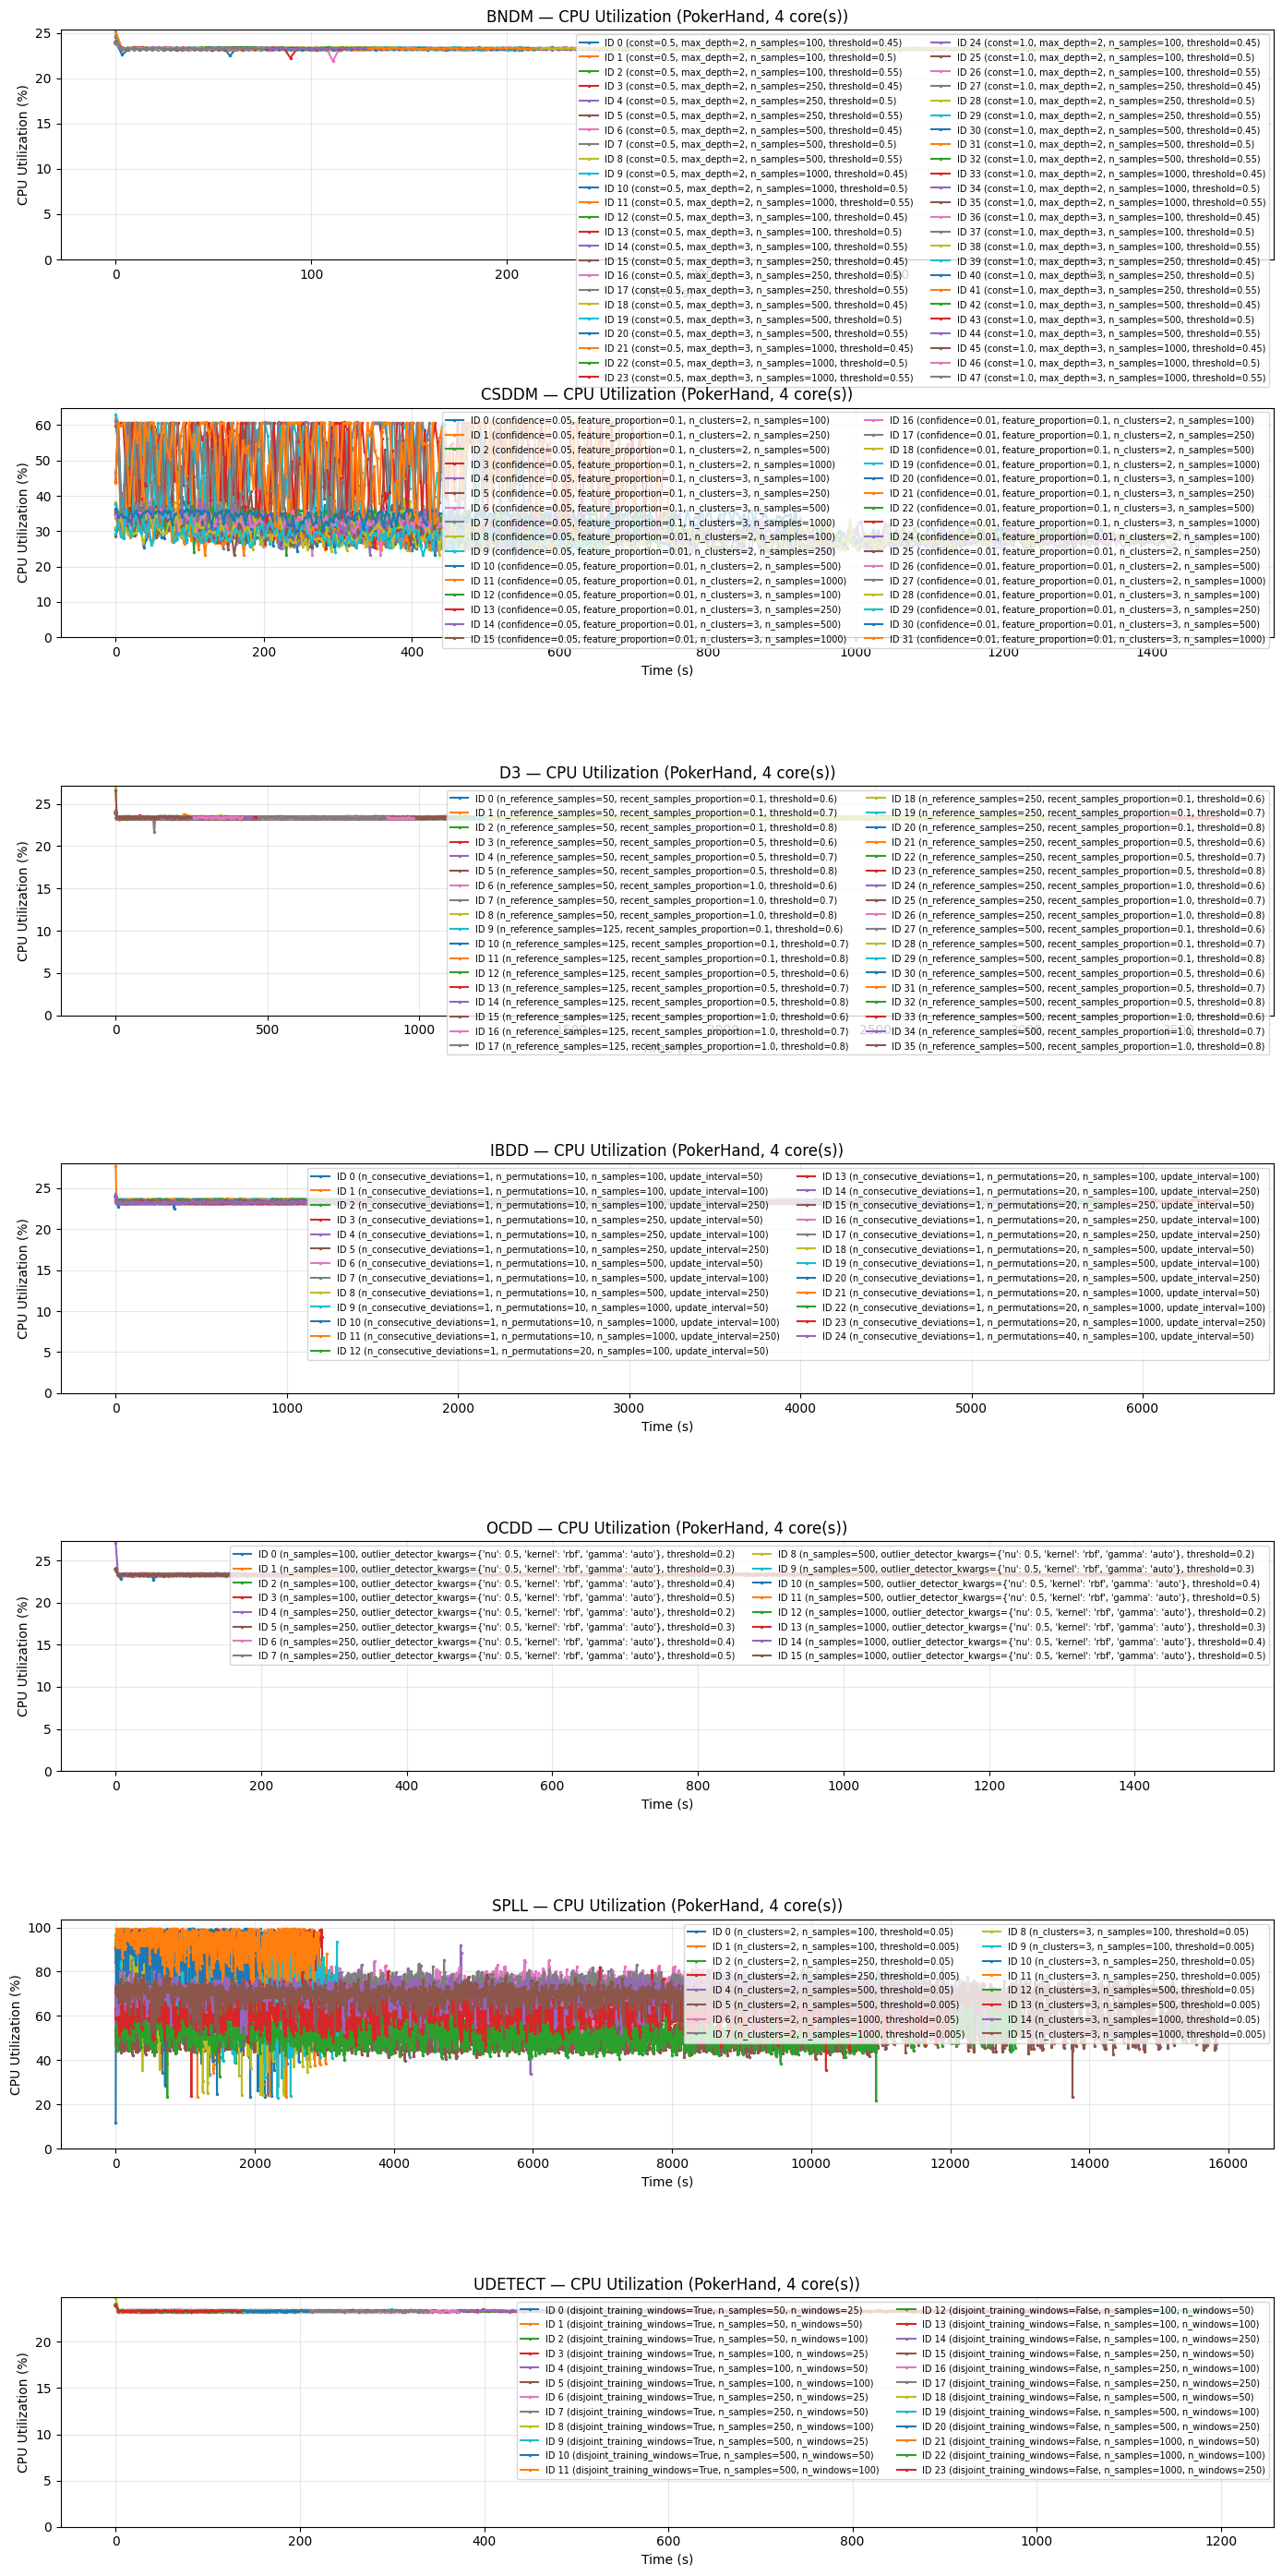

In [5]:
# Plot CPU utilization per detector for the selected core count
rdir = results_dir(BASE_DIR, NUM_CORES)
fig, axes = plt.subplots(len(DETECTORS), 1, figsize=(14, 4 * len(DETECTORS)),
                         squeeze=False)

for idx, det in enumerate(DETECTORS):
    ax = axes[idx, 0]
    available_ids = discover_ids(DATASET, det, rdir)
    plot_ids = resolve_ids(SELECTED_IDS, available_ids)

    if not plot_ids:
        ax.set_title(f"{det.upper()} — no data")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("CPU Utilization (%)")
        continue

    config_path = os.path.join(rdir, f"{DATASET}_{det}.config")
    configs = {}
    if os.path.exists(config_path):
        configs = load_config_file(config_path)

    for cid in plot_ids:
        filepath = os.path.join(rdir, f"{DATASET}_{det}_{cid}.csv")
        if not os.path.exists(filepath):
            continue
        times, utils = load_cpu_csv(filepath)
        if len(times) == 0:
            continue
        label = f"ID {cid}"
        if cid in configs:
            params_str = ", ".join(f"{k}={v}" for k, v in configs[cid].items())
            label += f" ({params_str})"
        ax.plot(times, utils, marker=".", markersize=3, label=label)

    ax.set_title(f"{det.upper()} — CPU Utilization ({DATASET}, {NUM_CORES} core(s))")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("CPU Utilization (%)")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7, loc="upper right", ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Summary statistics for the selected core count
rdir = results_dir(BASE_DIR, NUM_CORES)
print(f"Core count: {NUM_CORES}")
print(f"{'Detector':<10} {'ID':>4} {'Samples':>8} {'Duration(s)':>12} "
      f"{'Mean CPU%':>10} {'Max CPU%':>10} {'Min CPU%':>10}")
print("-" * 70)

for det in DETECTORS:
    available_ids = discover_ids(DATASET, det, rdir)
    plot_ids = resolve_ids(SELECTED_IDS, available_ids)
    for cid in plot_ids:
        filepath = os.path.join(rdir, f"{DATASET}_{det}_{cid}.csv")
        if not os.path.exists(filepath):
            continue
        times, utils = load_cpu_csv(filepath)
        if len(times) == 0:
            continue
        duration = times[-1] - times[0] if len(times) > 1 else 0
        print(f"{det.upper():<10} {cid:>4} {len(times):>8} {duration:>12.1f} "
              f"{np.mean(utils):>10.2f} {np.max(utils):>10.2f} {np.min(utils):>10.2f}")

Core count: 4
Detector     ID  Samples  Duration(s)  Mean CPU%   Max CPU%   Min CPU%
----------------------------------------------------------------------
BNDM          0      172        517.1      23.25      24.00      22.49
BNDM          1      172        525.7      23.28      23.86      23.16
BNDM          2      172        538.1      23.30      23.95      23.19
BNDM          3       68        207.0      23.28      24.57      22.26
BNDM          4       68        206.5      23.28      23.90      23.16
BNDM          5       68        206.1      23.29      23.89      23.18
BNDM          6       41        123.1      23.29      23.94      23.19
BNDM          7       41        122.7      23.28      23.91      23.18
BNDM          8       42        125.4      23.30      23.91      23.19
BNDM          9       25         73.5      23.34      24.77      23.21
BNDM         10       25         73.7      23.32      23.94      23.19
BNDM         11       25         73.7      23.31      23.88    

## Speedup Plot

Computes speedup relative to the 1-core baseline for each detector and config ID.

**Speedup(n) = Duration(1 core) / Duration(n cores)**

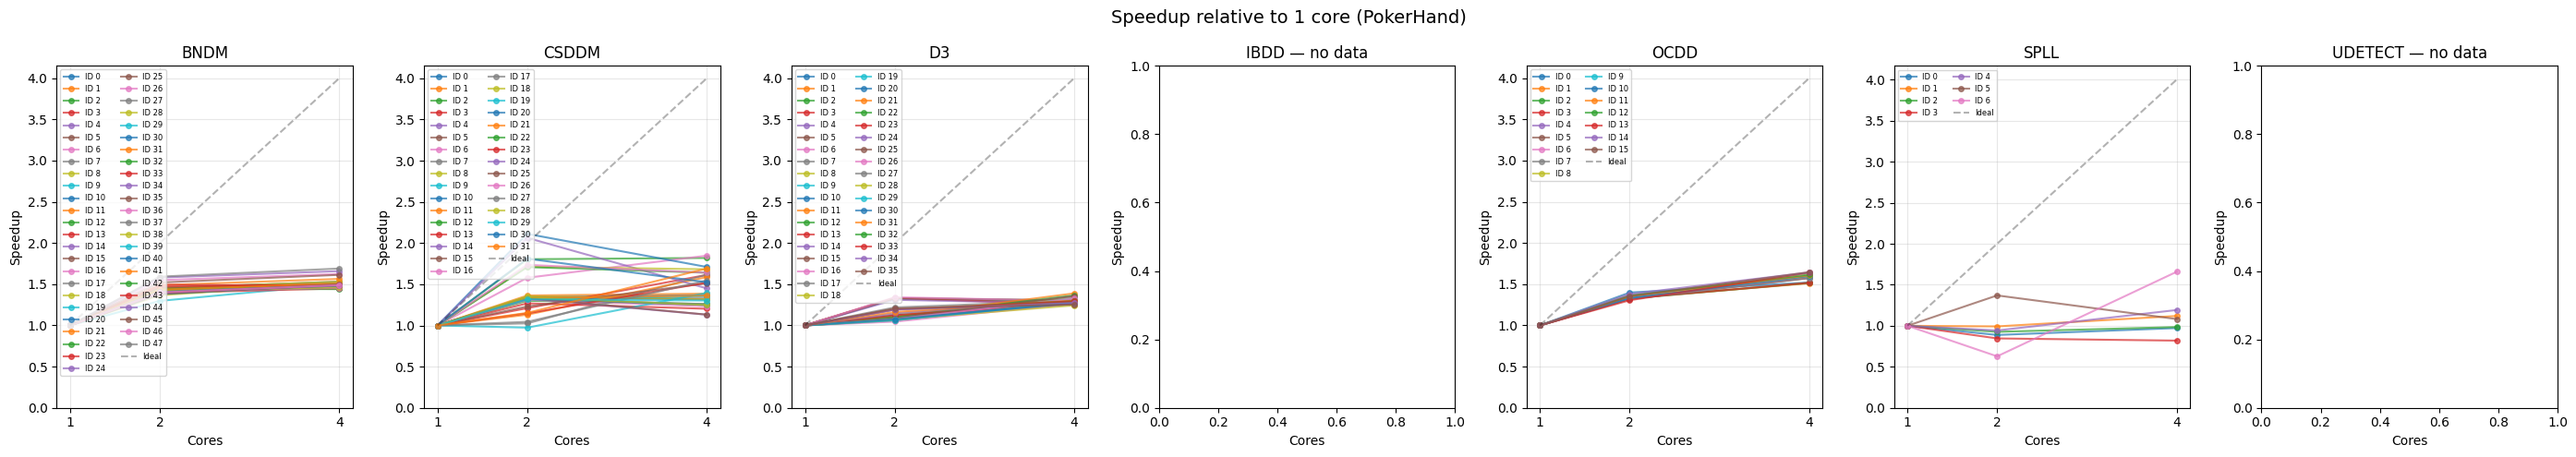

In [7]:
# Compute speedup: base is 1-core duration, compare with 2 and 4 cores
base_cores = ALL_CORE_COUNTS[0]  # 1 core is the baseline
base_dir = results_dir(BASE_DIR, base_cores)

fig, axes = plt.subplots(1, len(DETECTORS), figsize=(4 * len(DETECTORS), 5),
                         squeeze=False)

for idx, det in enumerate(DETECTORS):
    ax = axes[0, idx]

    # Find IDs available across ALL core counts
    common_ids = None
    for cores in ALL_CORE_COUNTS:
        rdir = results_dir(BASE_DIR, cores)
        ids_set = set(discover_ids(DATASET, det, rdir))
        common_ids = ids_set if common_ids is None else common_ids & ids_set
    common_ids = sorted(common_ids) if common_ids else []
    plot_ids = resolve_ids(SELECTED_IDS, common_ids)

    if not plot_ids:
        ax.set_title(f"{det.upper()} — no data")
        ax.set_xlabel("Cores")
        ax.set_ylabel("Speedup")
        continue

    for cid in plot_ids:
        # Get baseline duration (1 core)
        base_file = os.path.join(base_dir, f"{DATASET}_{det}_{cid}.csv")
        base_duration = get_duration(base_file)
        if base_duration is None or base_duration == 0:
            continue

        speedups = []
        for cores in ALL_CORE_COUNTS:
            rdir = results_dir(BASE_DIR, cores)
            filepath = os.path.join(rdir, f"{DATASET}_{det}_{cid}.csv")
            dur = get_duration(filepath)
            if dur is not None and dur > 0:
                speedups.append(base_duration / dur)
            else:
                speedups.append(np.nan)

        ax.plot(ALL_CORE_COUNTS, speedups, marker="o", markersize=4,
                label=f"ID {cid}", alpha=0.7)

    # Plot ideal speedup line
    ax.plot(ALL_CORE_COUNTS, ALL_CORE_COUNTS, "k--", alpha=0.3, label="Ideal")

    ax.set_title(f"{det.upper()}")
    ax.set_xlabel("Cores")
    ax.set_ylabel("Speedup")
    ax.set_xticks(ALL_CORE_COUNTS)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=6, loc="upper left", ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Speedup relative to {base_cores} core ({DATASET})", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Speedup summary table
base_dir = results_dir(BASE_DIR, base_cores)
print(f"{'Detector':<10} {'ID':>4}", end="")
for cores in ALL_CORE_COUNTS:
    print(f"  {'T(' + str(cores) + 'c)':>10}  {'S(' + str(cores) + 'c)':>8}", end="")
print()
print("-" * (14 + 22 * len(ALL_CORE_COUNTS)))

for det in DETECTORS:
    common_ids = None
    for cores in ALL_CORE_COUNTS:
        rdir = results_dir(BASE_DIR, cores)
        ids_set = set(discover_ids(DATASET, det, rdir))
        common_ids = ids_set if common_ids is None else common_ids & ids_set
    common_ids = sorted(common_ids) if common_ids else []
    plot_ids = resolve_ids(SELECTED_IDS, common_ids)

    for cid in plot_ids:
        base_file = os.path.join(base_dir, f"{DATASET}_{det}_{cid}.csv")
        base_duration = get_duration(base_file)
        if base_duration is None or base_duration == 0:
            continue
        print(f"{det.upper():<10} {cid:>4}", end="")
        for cores in ALL_CORE_COUNTS:
            rdir = results_dir(BASE_DIR, cores)
            filepath = os.path.join(rdir, f"{DATASET}_{det}_{cid}.csv")
            dur = get_duration(filepath)
            if dur is not None and dur > 0:
                speedup = base_duration / dur
                print(f"  {dur:>10.1f}  {speedup:>8.2f}", end="")
            else:
                print(f"  {'N/A':>10}  {'N/A':>8}", end="")
        print()

Detector     ID       T(1c)     S(1c)       T(2c)     S(2c)       T(4c)     S(4c)
--------------------------------------------------------------------------------
BNDM          0       762.0      1.00       536.5      1.42       517.1      1.47
BNDM          1       763.2      1.00       538.3      1.42       525.7      1.45
BNDM          2       782.1      1.00       551.9      1.42       538.1      1.45
BNDM          3       311.1      1.00       215.2      1.45       207.0      1.50
BNDM          4       309.7      1.00       215.5      1.44       206.5      1.50
BNDM          5       313.1      1.00       217.4      1.44       206.1      1.52
BNDM          6       199.8      1.00       128.9      1.55       123.1      1.62
BNDM          7       188.1      1.00       130.0      1.45       122.7      1.53
BNDM          8       188.1      1.00       129.4      1.45       125.4      1.50
BNDM          9       110.3      1.00        85.0      1.30        73.5      1.50
BNDM         10  

In [ ]:
# Highest CPU utilization configurations per detector — single plot
# Prints all configs where CPU utilization is higher than using 1 CPU
# and speedup >= 1 at 4 cores.
rdir = results_dir(BASE_DIR, NUM_CORES)
base_cores_sel = min(ALL_CORE_COUNTS)
max_cores = max(ALL_CORE_COUNTS)

fig, ax = plt.subplots(figsize=(14, 6))

for det in DETECTORS:
    available_ids = discover_ids(DATASET, det, rdir)
    if not available_ids:
        continue

    # Collect (cid, mean_util, speedup_at_max_cores) for all valid configs
    valid_configs = []
    for cid in available_ids:
        filepath = os.path.join(rdir, f"{DATASET}_{det}_{cid}.csv")
        if not os.path.exists(filepath):
            continue
        _, utils = load_cpu_csv(filepath)
        if len(utils) == 0:
            continue
        mean_util = np.mean(utils)

        base_fp = os.path.join(results_dir(BASE_DIR, base_cores_sel),
                               f"{DATASET}_{det}_{cid}.csv")
        top_fp = os.path.join(results_dir(BASE_DIR, max_cores),
                              f"{DATASET}_{det}_{cid}.csv")
        base_dur = get_duration(base_fp)
        top_dur = get_duration(top_fp)
        if base_dur is None or base_dur <= 0 or top_dur is None or top_dur <= 0:
            continue
        speedup = base_dur / top_dur
        if speedup >= 1.0:
            valid_configs.append((cid, mean_util, speedup))

    # Sort by mean CPU utilization descending
    valid_configs.sort(key=lambda t: t[1], reverse=True)

    if not valid_configs:
        print(f"WARNING [{det.upper()}]: No config found with speedup >= 1 "
              f"at {max_cores} cores. Skipping.")
        continue

    print(f"{det.upper()} — configs with speedup >= 1 at {max_cores} cores "
          f"(sorted by mean CPU%):")
    for cid, mu, sp in valid_configs:
        print(f"  ID {cid:>3}  Mean CPU% = {mu:.2f}  Speedup({max_cores}c) = {sp:.2f}")

    # Plot the one with highest CPU utilization
    best_id = valid_configs[0][0]
    filepath = os.path.join(rdir, f"{DATASET}_{det}_{best_id}.csv")
    times, utils = load_cpu_csv(filepath)
    ax.plot(times, utils, marker=".", markersize=3, label=det.upper())

ax.set_title(f"Highest CPU Utilization per Detector ({DATASET}, {NUM_CORES} core(s))")
ax.set_xlabel("Time (s)")
ax.set_ylabel("CPU Utilization (%)")
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Speedup bar charts — all configs with speedup >= 1 at max cores
# One separate plot per detector in FOCUS_DETECTORS
FOCUS_DETECTORS = ["csddm", "spll"]
base_cores_sel = min(ALL_CORE_COUNTS)
max_cores = max(ALL_CORE_COUNTS)

CORE_COLORS = {1: "#4C72B0", 2: "#55A868", 4: "#C44E52"}

for det in FOCUS_DETECTORS:
    rdir_top = results_dir(BASE_DIR, NUM_CORES)
    available_ids = discover_ids(DATASET, det, rdir_top)

    valid_configs = []
    for cid in available_ids:
        fp = os.path.join(rdir_top, f"{DATASET}_{det}_{cid}.csv")
        if not os.path.exists(fp):
            continue
        _, utils = load_cpu_csv(fp)
        if len(utils) == 0:
            continue
        mean_util = np.mean(utils)

        base_fp = os.path.join(results_dir(BASE_DIR, base_cores_sel),
                               f"{DATASET}_{det}_{cid}.csv")
        top_fp = os.path.join(results_dir(BASE_DIR, max_cores),
                              f"{DATASET}_{det}_{cid}.csv")
        base_dur = get_duration(base_fp)
        top_dur = get_duration(top_fp)
        if base_dur is None or base_dur <= 0 or top_dur is None or top_dur <= 0:
            continue
        speedup = base_dur / top_dur
        if speedup >= 1.0:
            valid_configs.append((cid, mean_util, speedup))

    valid_configs.sort(key=lambda t: t[1], reverse=True)

    if not valid_configs:
        print(f"WARNING [{det.upper()}]: No config found with higher CPU utilization "
              f"than 1 CPU and speedup >= 1 at {max_cores} cores.")
        continue

    print(f"{det.upper()} — {len(valid_configs)} configs with speedup >= 1 at "
          f"{max_cores} cores (sorted by mean CPU%):")
    for cid, mu, sp in valid_configs:
        print(f"  ID {cid:>3}  Mean CPU% = {mu:.2f}  Speedup({max_cores}c) = {sp:.2f}")
    print()

    config_ids = [c[0] for c in valid_configs]
    all_durations = {}
    all_speedups = {}
    for cid in config_ids:
        dur_map = {}
        for cores in ALL_CORE_COUNTS:
            rdir = results_dir(BASE_DIR, cores)
            fp = os.path.join(rdir, f"{DATASET}_{det}_{cid}.csv")
            dur = get_duration(fp)
            if dur is not None and dur > 0:
                dur_map[cores] = dur
        all_durations[cid] = dur_map
        base = dur_map.get(1)
        if base is not None and base > 0:
            all_speedups[cid] = {c: base / d for c, d in dur_map.items()}

    plot_cids = [cid for cid in config_ids if cid in all_speedups]
    n_configs = len(plot_cids)
    n_cores = len(ALL_CORE_COUNTS)
    bar_width = 0.6 / n_cores
    x = np.arange(n_configs)

    fig, ax = plt.subplots(figsize=(max(8, n_configs * 1.2), 5))

    for i, cores in enumerate(ALL_CORE_COUNTS):
        vals = [all_speedups[cid].get(cores, 0) for cid in plot_cids]
        color = CORE_COLORS.get(cores, None)
        bars = ax.bar(x + i * bar_width, vals, bar_width,
                      label=f"{cores} core(s)", color=color, edgecolor="white",
                      linewidth=0.5)
        for bar, cid in zip(bars, plot_cids):
            dur = all_durations[cid].get(cores)
            if dur is not None:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f"{dur:.0f}s", ha="center", va="bottom", fontsize=6,
                        rotation=90)

    ax.set_xlabel("Config ID")
    ax.set_ylabel("Speedup (relative to 1 core)")
    ax.set_title(f"{det.upper()} — Speedup for configs with speedup >= 1 ({DATASET})")
    ax.set_xticks(x + bar_width * (n_cores - 1) / 2)
    ax.set_xticklabels([str(cid) for cid in plot_cids], fontsize=7, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

In [ ]:
# Configurable speedup comparison — select specific (detector, config_id) pairs
# Edit PLOT_CONFIGS below to choose which configurations to compare.
PLOT_CONFIGS = [
    ("spll", 1),
    ("csddm", 31),
]

CORE_COLORS = {1: "#4C72B0", 2: "#55A868", 4: "#C44E52"}
base_cores_sel = min(ALL_CORE_COUNTS)

# Gather durations and speedups
labels = []
all_durations = {}
all_speedups = {}
for det, cid in PLOT_CONFIGS:
    key = f"{det.upper()} ID {cid}"
    dur_map = {}
    for cores in ALL_CORE_COUNTS:
        rdir = results_dir(BASE_DIR, cores)
        fp = os.path.join(rdir, f"{DATASET}_{det}_{cid}.csv")
        dur = get_duration(fp)
        if dur is not None and dur > 0:
            dur_map[cores] = dur
    base = dur_map.get(base_cores_sel)
    if base is None or base <= 0:
        print(f"WARNING: No 1-core baseline for {key}. Skipping.")
        continue
    all_durations[key] = dur_map
    all_speedups[key] = {c: base / d for c, d in dur_map.items()}
    labels.append(key)

# Print summary
hdr = "{:<20} {:>6} {:>12} {:>8}".format("Config", "Cores", "Duration(s)", "Speedup")
print(hdr)
print("-" * len(hdr))
for key in labels:
    for cores in ALL_CORE_COUNTS:
        dur = all_durations[key].get(cores)
        sp = all_speedups[key].get(cores)
        if dur is not None and sp is not None:
            print(f"{key:<20} {cores:>6} {dur:>12.1f} {sp:>8.2f}")
print()

# Bar chart
n_configs = len(labels)
n_cores = len(ALL_CORE_COUNTS)
bar_width = 0.6 / n_cores
x = np.arange(n_configs)

fig, ax = plt.subplots(figsize=(max(6, n_configs * 2.5), 5))

for i, cores in enumerate(ALL_CORE_COUNTS):
    vals = [all_speedups[key].get(cores, 0) for key in labels]
    color = CORE_COLORS.get(cores, None)
    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  label=f"{cores} core(s)", color=color, edgecolor="white",
                  linewidth=0.5)
    for bar, key in zip(bars, labels):
        dur = all_durations[key].get(cores)
        if dur is not None:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"{dur:.0f}s", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Configuration")
ax.set_ylabel("Speedup (relative to 1 core)")
ax.set_title(f"Speedup Comparison ({DATASET})")
ax.set_xticks(x + bar_width * (n_cores - 1) / 2)
ax.set_xticklabels(labels, fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

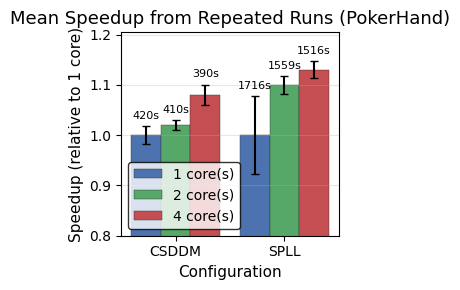

In [21]:
# Mean runtime speedup from repeated experiments
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

CORE_COLORS = {1: "#4C72B0", 2: "#55A868", 4: "#C44E52"}
ALL_CORE_COUNTS = [1, 2, 4]

# Data from runtime experiments (10 repetitions each)
data = {
    "CSDDM": {
        1: {"mean": 420.45, "std": 7.68, "min": 403.91, "max": 433.07, "speedup": 1.00},
        2: {"mean": 410.45, "std": 4.21, "min": 400.26, "max": 415.56, "speedup": 1.02},
        4: {"mean": 389.57, "std": 8.70, "min": 378.07, "max": 412.10, "speedup": 1.08},
    },
    "SPLL": {
        1: {"mean": 1715.53, "std": 133.64, "min": 1488.39, "max": 1879.02, "speedup": 1.00},
        2: {"mean": 1559.30, "std": 31.58, "min": 1484.55, "max": 1594.89, "speedup": 1.10},
        4: {"mean": 1515.81, "std": 29.34, "min": 1479.70, "max": 1566.52, "speedup": 1.13},
    },
}

labels = list(data.keys())
n_configs = len(labels)
n_cores = len(ALL_CORE_COUNTS)
bar_width = 0.12
group_width = n_cores * bar_width  # total width of one group
group_spacing = 0.08  # small gap between groups
x = np.arange(n_configs) * (group_width + group_spacing)

fig, ax = plt.subplots(figsize=(3, 3))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, cores in enumerate(ALL_CORE_COUNTS):
    vals = [data[lbl][cores]["speedup"] for lbl in labels]
    stds = [data[lbl][cores]["std"] / data[lbl][1]["mean"] for lbl in labels]
    color = CORE_COLORS[cores]
    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  yerr=stds, capsize=3,
                  label=f"{cores} core(s)", color=color, edgecolor="#333333",
                  linewidth=0.3)
    for j, (bar, lbl) in enumerate(zip(bars, labels)):
        mean_rt = data[lbl][cores]["mean"]
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + stds[j] + 0.01,
                f"{mean_rt:.0f}s", ha="center", va="bottom", fontsize=8,
                color="black")

ax.set_xlabel("Configuration", fontsize=11, color="black")
ax.set_ylabel("Speedup (relative to 1 core)", fontsize=11, color="black")
ax.set_title("Mean Speedup from Repeated Runs (PokerHand)", fontsize=13, color="black")
ax.set_xticks(x + bar_width * (n_cores - 1) / 2)
ax.set_xticklabels(labels, fontsize=10, color="black")
ax.tick_params(axis="y", colors="black")
ax.legend(facecolor="white", edgecolor="black")
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(bottom=0.8)
for spine in ax.spines.values():
    spine.set_edgecolor("black")

plt.tight_layout()
plt.savefig("mean_speedup_plot.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()